# HBV Multi-objective Calibration (Cal/Val Split)

This notebook implements a Monte Carlo calibration using a combined objective:
- NSE on raw flow
- NSE on log-flow
- relative bias penalty

It splits the record into calibration and validation periods and reports both.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from hbv_bmi_project import HBV_Bmi

In [2]:
# Paths
base = '/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'
temp_path = f'{base}/ERA5_Temp_1980_2026.csv'
precip_path = f'{base}/Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv'
evap_path = f'{base}/Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv'
grdc_path = '/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt'
shape_area = 28191724718  # m2

In [3]:
# Temperature
df_t = pd.read_csv(temp_path)
df_t['year'] = df_t['system:index'].astype(str).str[:4].astype(int)
df_t['month'] = df_t['system:index'].astype(str).str[4:6].astype(int)
df_t['temperature_C'] = df_t['temperature_2m'] - 273.15
temp_monthly = df_t.pivot_table(index='year', columns='month', values='temperature_C')
temp_monthly = temp_monthly.loc[1980:2020]
temp_array = temp_monthly.values.flatten()
delT_array = temp_array - np.mean(temp_array)

# Precip and evaporation
df_p = pd.read_csv(precip_path)
df_e = pd.read_csv(evap_path)
df_p = df_p[(df_p['system:index'] >= 198001) & (df_p['system:index'] <= 202012)].reset_index(drop=True)
df_e = df_e[(df_e['system:index'] >= 198001) & (df_e['system:index'] <= 202012)].reset_index(drop=True)

# GRDC daily to monthly mean
grdc = pd.read_csv(
    grdc_path,
    encoding='latin-1',
    sep=';',
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc.columns = ['q_m3s']
grdc['year'] = grdc.index.year
grdc['month'] = grdc.index.month
q_month = grdc.groupby(['year', 'month'])['q_m3s'].mean().reset_index()
q_month['Date'] = pd.to_datetime(q_month[['year', 'month']].assign(day=1))
q_month = q_month[(q_month['year'] >= 1980) & (q_month['year'] <= 2020)].sort_values('Date').reset_index(drop=True)

dates = pd.date_range('1980-01-01', '2020-12-01', freq='MS')
monthly_df = pd.DataFrame({
    'Date': dates,
    'precip_m_month': df_p['total_precipitation_sum'].values,
    'evap_m_month': df_e[df_e.columns[1]].values,
    'temperature_C': temp_array,
    'delT': delT_array,
    'q_m3s': q_month['q_m3s'].values,
})

monthly_df['days_in_month'] = monthly_df['Date'].dt.days_in_month
monthly_df['precip_mm_month'] = monthly_df['precip_m_month'] * 1000.0
monthly_df['pet_mm_month'] = (-monthly_df['evap_m_month']).clip(lower=0) * 1000.0
monthly_df['precip_mm_day'] = monthly_df['precip_mm_month'] / monthly_df['days_in_month']
monthly_df['pet_mm_day'] = monthly_df['pet_mm_month'] / monthly_df['days_in_month']
monthly_df['q_obs_mm_day'] = monthly_df['q_m3s'] * 86400.0 / shape_area * 1000.0

monthly_df.head()

,Date,precip_m_month,evap_m_month,temperature_C,delT,q_m3s,days_in_month,precip_mm_month,pet_mm_month,precip_mm_day,pet_mm_day,q_obs_mm_day
0,1980-01-01,0.077218,-0.006487,-1.001031,-10.451440,592.322581,31,77.218060,6.487182,2.490905,0.209264,1.815308
1,1980-02-01,0.081914,-0.021555,3.847232,-5.603177,896.241379,29,81.913982,21.554530,2.824620,0.743260,2.746737
2,1980-03-01,0.089754,-0.037676,4.629214,-4.821195,269.935484,31,89.754468,37.676348,2.895305,1.215366,0.827279
3,1980-04-01,0.060644,-0.064560,6.306908,-3.143501,293.433333,30,60.644102,64.560134,2.021470,2.152004,0.899294
4,1980-05-01,0.073371,-0.092885,10.861671,1.411262,180.354839,31,73.371170,92.885477,2.366812,2.996306,0.552739


In [4]:
# Build model inputs
time_index = pd.DatetimeIndex(monthly_df['Date'].values)
precip_array = monthly_df['precip_mm_day'].to_numpy()
evap_array = monthly_df['pet_mm_day'].to_numpy()
temp_input = monthly_df['delT'].to_numpy()  # current HBV uses DelT directly
q_obs = monthly_df['q_obs_mm_day'].to_numpy()

precip_da = xr.DataArray(precip_array, coords={'time': time_index}, dims=('time',), name='pr')
evap_da = xr.DataArray(evap_array, coords={'time': time_index}, dims=('time',), name='evspsblpot')
temp_da = xr.DataArray(temp_input, coords={'time': time_index}, dims=('time',), name='tas')

config = {
    'precipitation_file': precip_da,
    'potential_evaporation_file': evap_da,
    'temperature_file': temp_da,
    'initial_storage': '0.0,100.0,20.0,30.0',
}

# Calibration bounds (gamma constrained negative by hypothesis)
ParMinn = np.array([0.0, 0.2, 80.0, 0.8, 0.01, 1.0, 0.01, 0.001, -0.03])
ParMaxn = np.array([4.0, 1.2, 500.0, 2.8, 0.15, 6.0, 0.06, 0.03, -0.001])

In [5]:
# Metrics and objective
def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    den = np.sum((obs - np.mean(obs)) ** 2)
    if den <= 0:
        return np.nan
    return 1 - (np.sum((obs - sim) ** 2) / den)

def log_nse(obs, sim, eps=1e-6):
    obs = np.maximum(np.asarray(obs, dtype=float), eps)
    sim = np.maximum(np.asarray(sim, dtype=float), eps)
    return nse(np.log(obs), np.log(sim))

def rel_bias(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    s_obs = np.sum(obs)
    if s_obs == 0:
        return np.nan
    return (np.sum(sim) - s_obs) / s_obs

def combined_score(obs, sim, w_nse=0.5, w_lognse=0.4, w_bias=0.1):
    n1 = nse(obs, sim)
    n2 = log_nse(obs, sim)
    b = rel_bias(obs, sim)
    if not (np.isfinite(n1) and np.isfinite(n2) and np.isfinite(b)):
        return np.nan
    return w_nse * n1 + w_lognse * n2 - w_bias * abs(b)

In [6]:
# Cal/Val split (time-based)
years = pd.DatetimeIndex(time_index).year
cal_mask = (years >= 1980) & (years <= 2005)
val_mask = (years >= 2006) & (years <= 2020)

spinup_steps = 24  # months
cal_idx = np.where(cal_mask)[0]
val_idx = np.where(val_mask)[0]

print('Calibration period:', time_index[cal_idx[0]], 'to', time_index[cal_idx[-1]])
print('Validation period :', time_index[val_idx[0]], 'to', time_index[val_idx[-1]])

Calibration period: 1980-01-01 00:00:00 to 2005-12-01 00:00:00
Validation period : 2006-01-01 00:00:00 to 2020-12-01 00:00:00


In [7]:
# Monte Carlo calibration
N = 800  # increase later if needed
runs = []

for _ in range(N):
    p = np.random.uniform(ParMinn, ParMaxn)
    m = HBV_Bmi()
    m.initialize(config)
    m.set_pars(p)

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    # Apply spin-up globally
    sim_s = sim[spinup_steps:]
    obs_s = q_obs[spinup_steps:]
    years_s = years[spinup_steps:]

    c_mask = (years_s >= 1980) & (years_s <= 2005)
    v_mask = (years_s >= 2006) & (years_s <= 2020)

    s_cal = combined_score(obs_s[c_mask], sim_s[c_mask])
    s_val = combined_score(obs_s[v_mask], sim_s[v_mask])

    if np.isfinite(s_cal):
        runs.append({
            'score_cal': s_cal,
            'score_val': s_val,
            'params': p,
            'sim': sim
        })

if len(runs) == 0:
    raise RuntimeError('No stable runs. Narrow bounds or reduce N and debug ranges.')

best = max(runs, key=lambda d: d['score_cal'])
best_params = best['params']
best_sim = best['sim']

print('Accepted runs:', len(runs), '/', N)
print('Best cal score:', best['score_cal'])
print('Best val score:', best['score_val'])
print('Best params:', best_params)

Accepted runs: 800 / 800
Best cal score: -20.65927920533458
Best val score: -17.50777680741566
Best params: [ 2.88347412e+00  2.12365804e-01  3.33313370e+02  2.69418539e+00
  1.05843637e-01  3.28077132e+00  5.57913163e-02  9.11470418e-03
 -2.89205775e-02]


In [8]:
# Report core metrics for best run
sim_s = best_sim[spinup_steps:]
obs_s = q_obs[spinup_steps:]
years_s = years[spinup_steps:]

c_mask = (years_s >= 1980) & (years_s <= 2005)
v_mask = (years_s >= 2006) & (years_s <= 2020)

metrics = pd.DataFrame({
    'period': ['cal', 'val'],
    'NSE': [nse(obs_s[c_mask], sim_s[c_mask]), nse(obs_s[v_mask], sim_s[v_mask])],
    'logNSE': [log_nse(obs_s[c_mask], sim_s[c_mask]), log_nse(obs_s[v_mask], sim_s[v_mask])],
    'rel_bias': [rel_bias(obs_s[c_mask], sim_s[c_mask]), rel_bias(obs_s[v_mask], sim_s[v_mask])]
})
metrics

,period,NSE,logNSE,rel_bias
0,cal,-35.216783,-6.441007,4.744848
1,val,-29.387927,-5.985007,4.198105


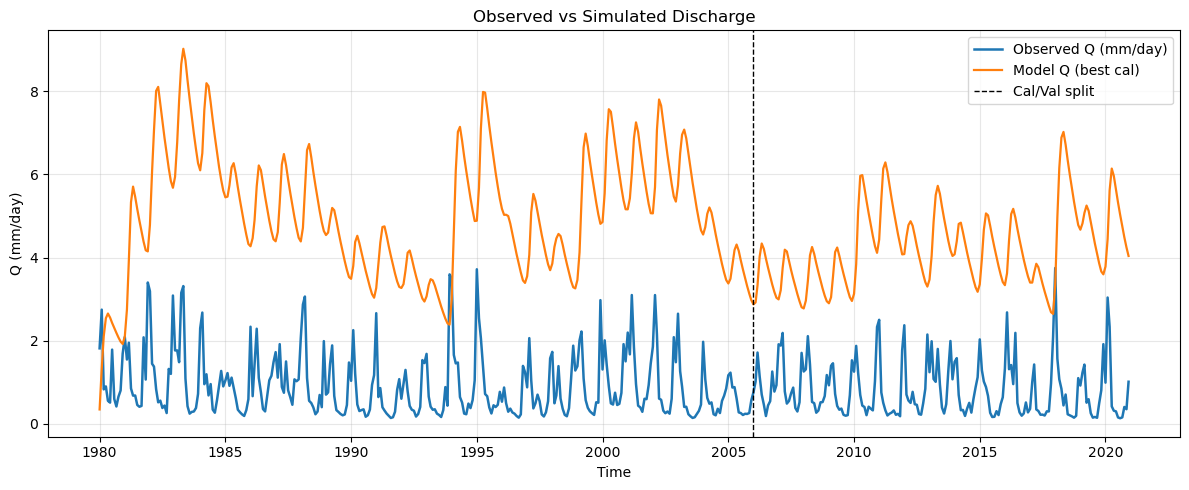

In [9]:
# Plot observed vs best simulation with split marker
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time_index, q_obs, label='Observed Q (mm/day)', lw=1.8)
ax.plot(time_index, best_sim, label='Model Q (best cal)', lw=1.6)
ax.axvline(pd.Timestamp('2006-01-01'), color='k', ls='--', lw=1, label='Cal/Val split')
ax.set_title('Observed vs Simulated Discharge')
ax.set_xlabel('Time')
ax.set_ylabel('Q (mm/day)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Save best run series
result_df = pd.DataFrame({
    'time': time_index,
    'q_obs_mm_day': q_obs,
    'q_sim_mm_day': best_sim,
    'year': years
})
result_df.head()

,time,q_obs_mm_day,q_sim_mm_day,year
0,1980-01-01,1.815308,0.344704,1980
1,1980-02-01,2.746737,1.329636,1980
2,1980-03-01,0.827279,2.103976,1980
3,1980-04-01,0.899294,2.540219,1980
4,1980-05-01,0.552739,2.653398,1980


In [11]:
summary = {}
summary['accepted_runs'] = len(runs)
summary['total_runs'] = N
summary['best_cal_score'] = float(best['score_cal'])
summary['best_val_score'] = float(best['score_val']) if np.isfinite(best['score_val']) else np.nan
summary['gamma_best'] = float(best_params[8])

sim_s = best_sim[spinup_steps:]
obs_s = q_obs[spinup_steps:]
years_s = years[spinup_steps:]
cal_mask_s = (years_s >= 1980) & (years_s <= 2005)
val_mask_s = (years_s >= 2006) & (years_s <= 2020)

summary['NSE_cal'] = float(nse(obs_s[cal_mask_s], sim_s[cal_mask_s]))
summary['NSE_val'] = float(nse(obs_s[val_mask_s], sim_s[val_mask_s]))
summary['logNSE_cal'] = float(log_nse(obs_s[cal_mask_s], sim_s[cal_mask_s]))
summary['logNSE_val'] = float(log_nse(obs_s[val_mask_s], sim_s[val_mask_s]))
summary['rel_bias_cal'] = float(rel_bias(obs_s[cal_mask_s], sim_s[cal_mask_s]))
summary['rel_bias_val'] = float(rel_bias(obs_s[val_mask_s], sim_s[val_mask_s]))

pd.Series(summary)

accepted_runs     800.000000
total_runs        800.000000
best_cal_score    -20.659279
best_val_score    -17.507777
gamma_best         -0.028921
NSE_cal           -35.216783
NSE_val           -29.387927
logNSE_cal         -6.441007
logNSE_val         -5.985007
rel_bias_cal        4.744848
rel_bias_val        4.198105
dtype: float64